# Introduction

Google's **FunctionGemma** is a lightweight 270M parameter model specifically designed for function calling. At just **550MB of RAM**, it can run on mobile devices while achieving ~50 tokens/second.

> **Note**: This notebook requires a GPU and is designed to run in **Google Colab** (free T4 GPU). Click Runtime → Change runtime type → Select T4 GPU.

This notebook demonstrates:
1. Creating practical CSV datasets for analysis
2. Defining Python functions for data querying
3. Zero-shot FunctionGemma performance
4. Fine-tuning FunctionGemma on custom data
5. Comparing zero-shot vs fine-tuned results

## Why FunctionGemma?

- **Tiny**: 270M parameters (vs GPT-3.5's 175B)
- **Fast**: ~50 tokens/sec on mobile
- **Efficient**: 550MB RAM in full precision
- **Fine-tunable**: Designed for task-specific training
- **Multi-turn**: Supports conversation + tool use

## Use Case: CSV Data Analysis

We'll create 5 CSV datasets representing common data analysis scenarios:
1. **Sales data** - Revenue, products, regions
2. **Employee records** - Departments, salaries, roles
3. **Weather data** - Temperature, precipitation
4. **Sensor readings** - IoT time-series data
5. **Customer reviews** - Ratings, sentiment

Then build Python functions to query them and see how FunctionGemma learns to use them correctly.

# Setup

In [1]:
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !uv pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !uv pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !uv pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !uv pip install --no-deps unsloth
!uv pip install transformers==4.57.3
!uv pip install --no-deps trl==0.22.2

Using Python 3.12.12 environment at: /usr
Resolved 8 packages in 3ms                                           
Audited 8 packages in 0.80ms
Using Python 3.12.12 environment at: /usr
Audited 5 packages in 86ms
Using Python 3.12.12 environment at: /usr
Resolved 1 package in 1ms                                            
Audited 1 package in 0.29ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 124ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 126ms


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Any

# Create data directory
Path("data").mkdir(exist_ok=True)

print("Setup complete")
%config InlineBackend.figure_format = 'retina'

Setup complete


# Step 1: Create CSV Datasets

Let's create realistic datasets for our analysis.

## Dataset 1: Sales Data

In [4]:
# Generate sales data
np.random.seed(42)
n_sales = 200

sales_data = pd.DataFrame({
    'date': pd.date_range(start='2024-01-01', periods=n_sales, freq='D'),
    'product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Headphones', 'Smartwatch'], n_sales),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_sales),
    'quantity': np.random.randint(1, 20, n_sales),
    'price': np.random.uniform(50, 2000, n_sales).round(2),
})
sales_data['revenue'] = (sales_data['quantity'] * sales_data['price']).round(2)

sales_data.to_csv('data/sales.csv', index=False)
print(f"Created sales.csv with {len(sales_data)} records")
sales_data.head()

Created sales.csv with 200 records


,date,product,region,quantity,price,revenue
0,2024-01-01,Headphones,South,2,1050.99,2101.98
1,2024-01-02,Smartwatch,South,10,504.79,5047.90
2,2024-01-03,Tablet,South,2,1183.55,2367.10
3,2024-01-04,Smartwatch,East,17,1733.12,29463.04
4,2024-01-05,Smartwatch,East,8,1766.70,14133.60


## Dataset 2: Employee Records

In [5]:
# Generate employee data
n_employees = 100

employees_data = pd.DataFrame({
    'employee_id': range(1, n_employees + 1),
    'name': [f'Employee_{i}' for i in range(1, n_employees + 1)],
    'department': np.random.choice(['Engineering', 'Sales', 'Marketing', 'HR', 'Finance'], n_employees),
    'role': np.random.choice(['Junior', 'Mid', 'Senior', 'Lead', 'Manager'], n_employees),
    'salary': np.random.randint(40000, 200000, n_employees),
    'years_experience': np.random.randint(0, 20, n_employees),
    'performance_score': np.random.uniform(2.5, 5.0, n_employees).round(2)
})

employees_data.to_csv('data/employees.csv', index=False)
print(f"Created employees.csv with {len(employees_data)} records")
employees_data.head()

Created employees.csv with 100 records


,employee_id,name,department,role,salary,years_experience,performance_score
0,1,Employee_1,HR,Lead,95176,14,4.87
1,2,Employee_2,Sales,Senior,174869,7,3.49
2,3,Employee_3,Engineering,Senior,184790,1,4.89
3,4,Employee_4,Engineering,Junior,74560,2,2.84
4,5,Employee_5,Sales,Lead,116589,13,3.71


## Dataset 3: Weather Data

In [6]:
# Generate weather data
n_days = 365

weather_data = pd.DataFrame({
    'date': pd.date_range(start='2024-01-01', periods=n_days, freq='D'),
    'city': np.random.choice(['New York', 'London', 'Tokyo', 'Sydney'], n_days),
    'temperature': np.random.uniform(-5, 35, n_days).round(1),
    'humidity': np.random.uniform(30, 95, n_days).round(1),
    'precipitation': np.random.uniform(0, 50, n_days).round(1),
    'wind_speed': np.random.uniform(0, 30, n_days).round(1)
})

weather_data.to_csv('data/weather.csv', index=False)
print(f"Created weather.csv with {len(weather_data)} records")
weather_data.head()

Created weather.csv with 365 records


,date,city,temperature,humidity,precipitation,wind_speed
0,2024-01-01,Sydney,14.3,94.6,40.1,20.4
1,2024-01-02,London,-0.3,73.0,22.9,10.9
2,2024-01-03,London,0.0,66.3,24.1,17.8
3,2024-01-04,Sydney,22.4,77.5,6.7,0.3
4,2024-01-05,London,12.2,60.2,4.0,19.1


## Dataset 4: Sensor Readings

In [7]:
# Generate sensor data
n_readings = 500

sensor_data = pd.DataFrame({
    'timestamp': pd.date_range(start='2024-01-01', periods=n_readings, freq='H'),
    'sensor_id': np.random.choice(['S001', 'S002', 'S003', 'S004', 'S005'], n_readings),
    'location': np.random.choice(['Building_A', 'Building_B', 'Building_C'], n_readings),
    'temperature': np.random.uniform(18, 28, n_readings).round(2),
    'co2_level': np.random.uniform(400, 1200, n_readings).round(0),
    'occupancy': np.random.randint(0, 50, n_readings)
})

sensor_data.to_csv('data/sensors.csv', index=False)
print(f"Created sensors.csv with {len(sensor_data)} records")
sensor_data.head()

Created sensors.csv with 500 records


/tmp/ipython-input-773869916.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range(start='2024-01-01', periods=n_readings, freq='H'),


,timestamp,sensor_id,location,temperature,co2_level,occupancy
0,2024-01-01 00:00:00,S002,Building_A,18.14,1044.0,45
1,2024-01-01 01:00:00,S004,Building_B,25.64,1157.0,33
2,2024-01-01 02:00:00,S001,Building_B,24.24,720.0,47
3,2024-01-01 03:00:00,S004,Building_B,25.62,1027.0,2
4,2024-01-01 04:00:00,S003,Building_B,18.39,613.0,25


## Dataset 5: Customer Reviews

In [8]:
# Generate review data
n_reviews = 150

reviews_data = pd.DataFrame({
    'review_id': range(1, n_reviews + 1),
    'product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Headphones'], n_reviews),
    'rating': np.random.choice([1, 2, 3, 4, 5], n_reviews, p=[0.05, 0.1, 0.15, 0.3, 0.4]),
    'verified_purchase': np.random.choice([True, False], n_reviews, p=[0.8, 0.2]),
    'helpful_votes': np.random.randint(0, 100, n_reviews),
    'date': pd.date_range(start='2024-01-01', periods=n_reviews, freq='D')
})

reviews_data.to_csv('data/reviews.csv', index=False)
print(f"Created reviews.csv with {len(reviews_data)} records")
reviews_data.head()

Created reviews.csv with 150 records


,review_id,product,rating,verified_purchase,helpful_votes,date
0,1,Phone,3,False,23,2024-01-01
1,2,Headphones,4,True,33,2024-01-02
2,3,Headphones,4,True,52,2024-01-03
3,4,Laptop,4,True,7,2024-01-04
4,5,Laptop,3,True,17,2024-01-05


# Step 2: Define Python Functions

Create functions that FunctionGemma will learn to call.

In [9]:
# Load all datasets
datasets = {
    'sales': pd.read_csv('data/sales.csv'),
    'employees': pd.read_csv('data/employees.csv'),
    'weather': pd.read_csv('data/weather.csv'),
    'sensors': pd.read_csv('data/sensors.csv'),
    'reviews': pd.read_csv('data/reviews.csv')
}

print("Loaded datasets:")
for name, df in datasets.items():
    print(f"  {name}: {len(df)} records")

Loaded datasets:
  sales: 200 records
  employees: 100 records
  weather: 365 records
  sensors: 500 records
  reviews: 150 records


In [10]:
# Define query functions

def get_total_revenue(dataset: str, product: str = None, region: str = None) -> float:
    """Calculate total revenue from sales data.
    
    Args:
        dataset: Name of dataset ('sales')
        product: Optional product filter
        region: Optional region filter
    """
    df = datasets[dataset].copy()
    
    if product:
        df = df[df['product'] == product]
    if region:
        df = df[df['region'] == region]
    
    return round(df['revenue'].sum(), 2)


def get_average_salary(dataset: str, department: str = None, role: str = None) -> float:
    """Calculate average salary from employee data.
    
    Args:
        dataset: Name of dataset ('employees')
        department: Optional department filter
        role: Optional role filter
    """
    df = datasets[dataset].copy()
    
    if department:
        df = df[df['department'] == department]
    if role:
        df = df[df['role'] == role]
    
    return round(df['salary'].mean(), 2) if len(df) > 0 else 0


def get_temperature_stats(dataset: str, city: str = None) -> Dict[str, float]:
    """Get temperature statistics from weather data.
    
    Args:
        dataset: Name of dataset ('weather')
        city: Optional city filter
    """
    df = datasets[dataset].copy()
    
    if city:
        df = df[df['city'] == city]
    
    return {
        'mean': round(df['temperature'].mean(), 2),
        'min': round(df['temperature'].min(), 2),
        'max': round(df['temperature'].max(), 2),
        'std': round(df['temperature'].std(), 2)
    }


def get_sensor_readings(dataset: str, sensor_id: str = None, 
                       location: str = None, metric: str = 'temperature') -> Dict[str, Any]:
    """Get sensor readings statistics.
    
    Args:
        dataset: Name of dataset ('sensors')
        sensor_id: Optional sensor ID filter
        location: Optional location filter
        metric: Metric to analyze ('temperature', 'co2_level', 'occupancy')
    """
    df = datasets[dataset].copy()
    
    if sensor_id:
        df = df[df['sensor_id'] == sensor_id]
    if location:
        df = df[df['location'] == location]
    
    return {
        'count': len(df),
        'mean': round(df[metric].mean(), 2),
        'median': round(df[metric].median(), 2),
        'latest': round(df[metric].iloc[-1], 2) if len(df) > 0 else None
    }


def get_review_stats(dataset: str, product: str = None, min_rating: int = None) -> Dict[str, Any]:
    """Get review statistics.
    
    Args:
        dataset: Name of dataset ('reviews')
        product: Optional product filter
        min_rating: Optional minimum rating filter
    """
    df = datasets[dataset].copy()
    
    if product:
        df = df[df['product'] == product]
    if min_rating:
        df = df[df['rating'] >= min_rating]
    
    return {
        'total_reviews': len(df),
        'average_rating': round(df['rating'].mean(), 2),
        'verified_percentage': round((df['verified_purchase'].sum() / len(df)) * 100, 2) if len(df) > 0 else 0
    }


# Create function registry
AVAILABLE_FUNCTIONS = {
    'get_total_revenue': get_total_revenue,
    'get_average_salary': get_average_salary,
    'get_temperature_stats': get_temperature_stats,
    'get_sensor_readings': get_sensor_readings,
    'get_review_stats': get_review_stats
}

print(f"Defined {len(AVAILABLE_FUNCTIONS)} functions")
for name in AVAILABLE_FUNCTIONS:
    print(f"  - {name}")

Defined 5 functions
  - get_total_revenue
  - get_average_salary
  - get_temperature_stats
  - get_sensor_readings
  - get_review_stats


# Step 3: Test Functions Directly

In [11]:
# Test each function
print("Testing functions:\n")

print("1. Total revenue for Laptops:", get_total_revenue('sales', product='Laptop'))
print("2. Average salary in Engineering:", get_average_salary('employees', department='Engineering'))
print("3. Temperature stats for Tokyo:", get_temperature_stats('weather', city='Tokyo'))
print("4. Sensor readings for S001:", get_sensor_readings('sensors', sensor_id='S001'))
print("5. Review stats for Phones:", get_review_stats('reviews', product='Phone'))

Testing functions:

1. Total revenue for Laptops: 341780.05
2. Average salary in Engineering: 135297.87
3. Temperature stats for Tokyo: {'mean': np.float64(14.06), 'min': -4.8, 'max': 34.9, 'std': 11.62}
4. Sensor readings for S001: {'count': 109, 'mean': np.float64(22.93), 'median': 22.65, 'latest': np.float64(24.71)}
5. Review stats for Phones: {'total_reviews': 43, 'average_rating': np.float64(3.72), 'verified_percentage': np.float64(79.07)}


# Step 4: Load FunctionGemma (Zero-Shot)

Load the base model and test its zero-shot function calling ability.

In [12]:
from unsloth import FastLanguageModel

# Load FunctionGemma
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/functiongemma-270m-it",
    max_seq_length=4096,
    load_in_4bit=True,
    dtype=None,
)

print("Loaded FunctionGemma model")
print(f"Model size: ~270M parameters")
print(f"Max sequence length: 4096")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.12.8: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Gemma3 does not support SDPA - switching to fast eager.
Loaded FunctionGemma model
Model size: ~270M parameters
Max sequence length: 4096


In [13]:
# Define function schemas for FunctionGemma
function_schemas = [
    {
        "name": "get_total_revenue",
        "description": "Calculate total revenue from sales data",
        "parameters": {
            "dataset": {"type": "string", "description": "Dataset name ('sales')"},
            "product": {"type": "string", "description": "Product name (optional)"},
            "region": {"type": "string", "description": "Region name (optional)"}
        }
    },
    {
        "name": "get_average_salary",
        "description": "Calculate average salary from employee data",
        "parameters": {
            "dataset": {"type": "string", "description": "Dataset name ('employees')"},
            "department": {"type": "string", "description": "Department name (optional)"},
            "role": {"type": "string", "description": "Role name (optional)"}
        }
    },
    {
        "name": "get_temperature_stats",
        "description": "Get temperature statistics from weather data",
        "parameters": {
            "dataset": {"type": "string", "description": "Dataset name ('weather')"},
            "city": {"type": "string", "description": "City name (optional)"}
        }
    },
    {
        "name": "get_sensor_readings",
        "description": "Get sensor readings statistics",
        "parameters": {
            "dataset": {"type": "string", "description": "Dataset name ('sensors')"},
            "sensor_id": {"type": "string", "description": "Sensor ID (optional)"},
            "location": {"type": "string", "description": "Location name (optional)"},
            "metric": {"type": "string", "description": "Metric to analyze (default: 'temperature')"}
        }
    },
    {
        "name": "get_review_stats",
        "description": "Get review statistics",
        "parameters": {
            "dataset": {"type": "string", "description": "Dataset name ('reviews')"},
            "product": {"type": "string", "description": "Product name (optional)"},
            "min_rating": {"type": "integer", "description": "Minimum rating filter (optional)"}
        }
    }
]

print(f"Defined {len(function_schemas)} function schemas")

Defined 5 function schemas


## Test Zero-Shot Performance

In [14]:
# Test questions
test_questions = [
    "What is the total revenue for Laptops in the North region?",
    "What's the average salary for Senior engineers?",
    "Show me temperature statistics for London",
    "What are the CO2 levels in Building_A?",
    "How many reviews does the Phone have with 4+ stars?"
]

print("Zero-Shot Test Questions:")
for i, q in enumerate(test_questions, 1):
    print(f"{i}. {q}")

Zero-Shot Test Questions:
1. What is the total revenue for Laptops in the North region?
2. What's the average salary for Senior engineers?
3. Show me temperature statistics for London
4. What are the CO2 levels in Building_A?
5. How many reviews does the Phone have with 4+ stars?


# Step 5: Create Fine-Tuning Dataset

Generate training examples showing correct function calls.

In [26]:
# Create comprehensive training examples (40+ examples)
training_examples = [
    # Sales queries - 10 examples
    {"question": "What is the total revenue from Laptop sales?",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "product": "Laptop"}},
    {"question": "Calculate total revenue for the East region",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "region": "East"}},
    {"question": "How much revenue did we get from Phones in the South?",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "product": "Phone", "region": "South"}},
    {"question": "Total revenue from Tablets",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "product": "Tablet"}},
    {"question": "What's the revenue in the West region?",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "region": "West"}},
    {"question": "Smartwatch sales revenue in the North",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "product": "Smartwatch", "region": "North"}},
    {"question": "Calculate Headphones revenue",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "product": "Headphones"}},
    {"question": "Total sales in South region",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "region": "South"}},
    {"question": "What's the overall revenue?",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales"}},
    {"question": "Laptop revenue in East",
     "function": "get_total_revenue",
     "parameters": {"dataset": "sales", "product": "Laptop", "region": "East"}},
    
    # Employee queries - 10 examples
    {"question": "What's the average salary in Engineering?",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "department": "Engineering"}},
    {"question": "Average salary for Senior role?",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "role": "Senior"}},
    {"question": "What do Marketing Managers earn on average?",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "department": "Marketing", "role": "Manager"}},
    {"question": "Average pay in Sales department",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "department": "Sales"}},
    {"question": "What do Junior employees earn?",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "role": "Junior"}},
    {"question": "HR department average salary",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "department": "HR"}},
    {"question": "Lead role compensation",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "role": "Lead"}},
    {"question": "Finance Senior salaries",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "department": "Finance", "role": "Senior"}},
    {"question": "Overall average salary",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees"}},
    {"question": "Engineering Managers pay",
     "function": "get_average_salary",
     "parameters": {"dataset": "employees", "department": "Engineering", "role": "Manager"}},
    
    # Weather queries - 8 examples  
    {"question": "Show temperature statistics for New York",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather", "city": "New York"}},
    {"question": "What's the temperature range in Tokyo?",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather", "city": "Tokyo"}},
    {"question": "Temperature stats for London",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather", "city": "London"}},
    {"question": "How's the temperature in Sydney?",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather", "city": "Sydney"}},
    {"question": "Get weather temperature data for New York",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather", "city": "New York"}},
    {"question": "Tokyo weather temperatures",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather", "city": "Tokyo"}},
    {"question": "Overall temperature statistics",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather"}},
    {"question": "London temperature mean and range",
     "function": "get_temperature_stats",
     "parameters": {"dataset": "weather", "city": "London"}},
    
    # Sensor queries - 8 examples
    {"question": "What are the CO2 readings for sensor S001?",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "sensor_id": "S001", "metric": "co2_level"}},
    {"question": "Show occupancy data for Building_A",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "location": "Building_A", "metric": "occupancy"}},
    {"question": "Temperature readings from S002",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "sensor_id": "S002", "metric": "temperature"}},
    {"question": "CO2 levels in Building_B",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "location": "Building_B", "metric": "co2_level"}},
    {"question": "S003 temperature data",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "sensor_id": "S003", "metric": "temperature"}},
    {"question": "Building_C occupancy stats",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "location": "Building_C", "metric": "occupancy"}},
    {"question": "Get S004 CO2 measurements",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "sensor_id": "S004", "metric": "co2_level"}},
    {"question": "Overall sensor temperature readings",
     "function": "get_sensor_readings",
     "parameters": {"dataset": "sensors", "metric": "temperature"}},
    
    # Review queries - 8 examples
    {"question": "How many reviews does the Laptop have?",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews", "product": "Laptop"}},
    {"question": "What's the average rating for Headphones with 4+ stars?",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews", "product": "Headphones", "min_rating": 4}},
    {"question": "Phone review statistics",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews", "product": "Phone"}},
    {"question": "Tablet reviews with 5 stars",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews", "product": "Tablet", "min_rating": 5}},
    {"question": "Headphones review count",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews", "product": "Headphones"}},
    {"question": "High rated Laptop reviews (4+)",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews", "product": "Laptop", "min_rating": 4}},
    {"question": "Overall review statistics",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews"}},
    {"question": "Phone ratings 3 or higher",
     "function": "get_review_stats",
     "parameters": {"dataset": "reviews", "product": "Phone", "min_rating": 3}},
]

print(f"Created {len(training_examples)} training examples")
print("\nDistribution:")
print("  Sales: 10 examples")
print("  Employees: 10 examples")
print("  Weather: 8 examples")
print("  Sensors: 8 examples")
print("  Reviews: 8 examples")
print("\nSample:")
print(json.dumps(training_examples[0], indent=2))

Created 44 training examples

Distribution:
  Sales: 10 examples
  Employees: 10 examples
  Weather: 8 examples
  Sensors: 8 examples
  Reviews: 8 examples

Sample:
{
  "question": "What is the total revenue from Laptop sales?",
  "function": "get_total_revenue",
  "parameters": {
    "dataset": "sales",
    "product": "Laptop"
  }
}


In [27]:
# Convert to FunctionGemma format with system prompts
from datasets import Dataset

# Create function declarations for system prompt
def create_function_declarations():
    """Create function declarations in FunctionGemma format."""
    declarations = """You can call these functions to query data:

<function_list>
get_total_revenue(dataset: str, product: str = None, region: str = None) -> float
  Calculate total revenue from sales data. Dataset must be 'sales'.
  
get_average_salary(dataset: str, department: str = None, role: str = None) -> float
  Calculate average salary. Dataset must be 'employees'.
  Departments: Engineering, Sales, Marketing, HR, Finance
  Roles: Junior, Mid, Senior, Lead, Manager
  
get_temperature_stats(dataset: str, city: str = None) -> Dict
  Get temperature statistics. Dataset must be 'weather'.
  Cities: New York, London, Tokyo, Sydney
  Returns: mean, min, max, std
  
get_sensor_readings(dataset: str, sensor_id: str = None, location: str = None, metric: str = 'temperature') -> Dict
  Get sensor readings. Dataset must be 'sensors'.
  Sensor IDs: S001, S002, S003, S004, S005
  Locations: Building_A, Building_B, Building_C
  Metrics: temperature, co2_level, occupancy
  Returns: count, mean, median, latest
  
get_review_stats(dataset: str, product: str = None, min_rating: int = None) -> Dict
  Get review statistics. Dataset must be 'reviews'.
  Products: Laptop, Phone, Tablet, Headphones
  Returns: total_reviews, average_rating, verified_percentage
</function_list>

Call functions using this format:
<start_function_call>function_name({"param1": "value1", "param2": "value2"})<end_function_call>"""
    return declarations

FUNCTION_DECLARATIONS = create_function_declarations()

def create_training_prompt(example):
    """Create FunctionGemma-formatted training prompt with system context."""
    # Format function call
    func_call = f"{example['function']}({json.dumps(example['parameters'])})"
    
    # Create conversation with system context
    prompt = f"""<start_of_turn>system
{FUNCTION_DECLARATIONS}<end_of_turn>
<start_of_turn>user
{example['question']}<end_of_turn>
<start_of_turn>model
<start_function_call>{func_call}<end_function_call><end_of_turn>"""
    
    return {"text": prompt}

# Create dataset
train_data = [create_training_prompt(ex) for ex in training_examples]
train_dataset = Dataset.from_list(train_data)

print(f"Created training dataset with {len(train_dataset)} examples")
print(f"Each example includes system prompt with function declarations")
print("\nSample formatted prompt:")
print(train_dataset[0]['text'][:500] + "...")

Created training dataset with 44 examples
Each example includes system prompt with function declarations

Sample formatted prompt:
<start_of_turn>system
You can call these functions to query data:

<function_list>
get_total_revenue(dataset: str, product: str = None, region: str = None) -> float
  Calculate total revenue from sales data. Dataset must be 'sales'.
  
get_average_salary(dataset: str, department: str = None, role: str = None) -> float
  Calculate average salary. Dataset must be 'employees'.
  Departments: Engineering, Sales, Marketing, HR, Finance
  Roles: Junior, Mid, Senior, Lead, Manager
  
get_temperature_st...


# Step 6: Fine-Tune FunctionGemma

In [28]:
from trl import SFTTrainer
from transformers import TrainingArguments

# Prepare model for training
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

print("Prepared model for LoRA fine-tuning")

RuntimeError: Unsloth: You already added LoRA adapters to your model!

In [29]:
# Training arguments
training_args = TrainingArguments(
    output_dir="./functiongemma-finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    optim="adamw_8bit",
    warmup_steps=5,
)

# Create trainer
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    dataset_text_field="text",
    max_seq_length=512,
    args=training_args,
)

print("Trainer initialized")
print(f"Training for {training_args.num_train_epochs} epochs")

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/44 [00:00<?, ? examples/s]

Trainer initialized
Training for 3 epochs


In [30]:
# Start training
print("Starting fine-tuning...\n")
trainer.train()
print("\nFine-tuning complete!")

Starting fine-tuning...



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44 | Num Epochs = 3 | Total steps = 18
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 3,796,992 of 271,895,168 (1.40% trained)


Step,Training Loss
10,2.007900


wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run


train/epoch,▁█
train/global_step,▁█
train/grad_norm,▁
train/learning_rate,▁
train/loss,▁
total_flos,36338513299968.0
train/epoch,3
train/global_step,18
train/grad_norm,2.95308
train/learning_rate,0.00014
train/loss,2.0079



Fine-tuning complete!


# Step 7: Compare Zero-Shot vs Fine-Tuned

Test both models on the same questions.

In [31]:
def test_model(model, tokenizer, question, max_new_tokens=128):
    """Test model on a question with function context."""
    # Include function declarations in prompt
    prompt = f"""<start_of_turn>system
{FUNCTION_DECLARATIONS}<end_of_turn>
<start_of_turn>user
{question}<end_of_turn>
<start_of_turn>model
"""
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,  # Lower temperature for more focused outputs
        top_k=50,
        top_p=0.9,
        do_sample=True,
    )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return response.split("<start_of_turn>model")[-1].strip()

print("Test function ready with system prompts")

Test function ready with system prompts


In [32]:
# Load original model for comparison
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/functiongemma-270m-it",
    max_seq_length=4096,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(base_model)

# Prepare fine-tuned model for inference
FastLanguageModel.for_inference(model)

print("Models ready for comparison")

==((====))==  Unsloth 2025.12.8: Fast Gemma3 patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.
Unsloth: Gemma3 does not support SDPA - switching to fast eager.
Models ready for comparison


In [33]:
# Compare on test questions
test_questions = [
    "What is the total revenue for Laptops in the North region?",
    "What's the average salary for Senior employees in Engineering?",
    "Show me temperature statistics for London",
    "What are the CO2 levels in Building_A?",
]

results = []

for question in test_questions:
    print(f"\n{'='*80}")
    print(f"Question: {question}")
    print(f"{'='*80}")
    
    # Zero-shot
    print("\n[Zero-Shot Model]")
    zero_shot = test_model(base_model, base_tokenizer, question)
    print(zero_shot)
    
    # Fine-tuned
    print("\n[Fine-Tuned Model]")
    fine_tuned = test_model(model, tokenizer, question)
    print(fine_tuned)
    
    results.append({
        'question': question,
        'zero_shot': zero_shot,
        'fine_tuned': fine_tuned
    })


Question: What is the total revenue for Laptops in the North region?

[Zero-Shot Model]
system
You can call these functions to query data:

<function_list>
get_total_revenue(dataset: str, product: str = None, region: str = None) -> float
  Calculate total revenue from sales data. Dataset must be 'sales'.
  
get_average_salary(dataset: str, department: str = None, role: str = None) -> float
  Calculate average salary. Dataset must be 'employees'.
  Departments: Engineering, Sales, Marketing, HR, Finance
  Roles: Junior, Mid, Senior, Lead, Manager
  
get_temperature_stats(dataset: str, city: str = None) -> Dict
  Get temperature statistics. Dataset must be 'weather'.
  Cities: New York, London, Tokyo, Sydney
  Returns: mean, min, max, std
  
get_sensor_readings(dataset: str, sensor_id: str = None, location: str = None, metric: str = 'temperature') -> Dict
  Get sensor readings. Dataset must be 'sensors'.
  Sensor IDs: S001, S002, S003, S004, S005
  Locations: Building_A, Building_B, Bui

# Step 8: Execute Function Calls

Parse the model outputs and execute the functions.

In [34]:
import re

def parse_function_call(response):
    """Extract function name and parameters from model response."""
    # Look for <start_function_call>function_name({params})<end_function_call>
    pattern = r'<start_function_call>(\w+)\((.*)\)<end_function_call>'
    match = re.search(pattern, response)
    
    if match:
        func_name = match.group(1)
        params_str = match.group(2)
        try:
            params = json.loads(params_str)
            return func_name, params
        except:
            return None, None
    return None, None

def execute_function_call(func_name, params):
    """Execute the function call."""
    if func_name in AVAILABLE_FUNCTIONS:
        try:
            result = AVAILABLE_FUNCTIONS[func_name](**params)
            return result
        except Exception as e:
            return f"Error: {str(e)}"
    return "Function not found"

print("Function execution utilities ready")

Function execution utilities ready


In [35]:
# Execute and compare results
comparison = []

for result in results:
    print(f"\n{'='*80}")
    print(f"Question: {result['question']}")
    print(f"{'='*80}")
    
    # Parse zero-shot
    zs_func, zs_params = parse_function_call(result['zero_shot'])
    print(f"\nZero-Shot: {zs_func}({zs_params})")
    if zs_func:
        zs_result = execute_function_call(zs_func, zs_params)
        print(f"Result: {zs_result}")
    else:
        print("Result: Failed to parse function call")
        zs_result = None
    
    # Parse fine-tuned
    ft_func, ft_params = parse_function_call(result['fine_tuned'])
    print(f"\nFine-Tuned: {ft_func}({ft_params})")
    if ft_func:
        ft_result = execute_function_call(ft_func, ft_params)
        print(f"Result: {ft_result}")
    else:
        print("Result: Failed to parse function call")
        ft_result = None
    
    comparison.append({
        'question': result['question'],
        'zero_shot_success': zs_func is not None,
        'fine_tuned_success': ft_func is not None,
        'zero_shot_result': zs_result,
        'fine_tuned_result': ft_result
    })


Question: What is the total revenue for Laptops in the North region?

Zero-Shot: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function not found

Fine-Tuned: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function not found

Question: What's the average salary for Senior employees in Engineering?

Zero-Shot: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function not found

Fine-Tuned: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function not found

Question: Show me temperature statistics for London

Zero-Shot: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function not found

Fine-Tuned: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function not found

Question: What are the CO2 levels in Building_A?

Zero-Shot: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function not found

Fine-Tuned: function_name({'param1': 'value1', 'param2': 'value2'})
Result: Function

# Step 9: Results Analysis


PERFORMANCE COMPARISON

Zero-Shot Success Rate: 100.0%
Fine-Tuned Success Rate: 100.0%

Improvement: +0.0%


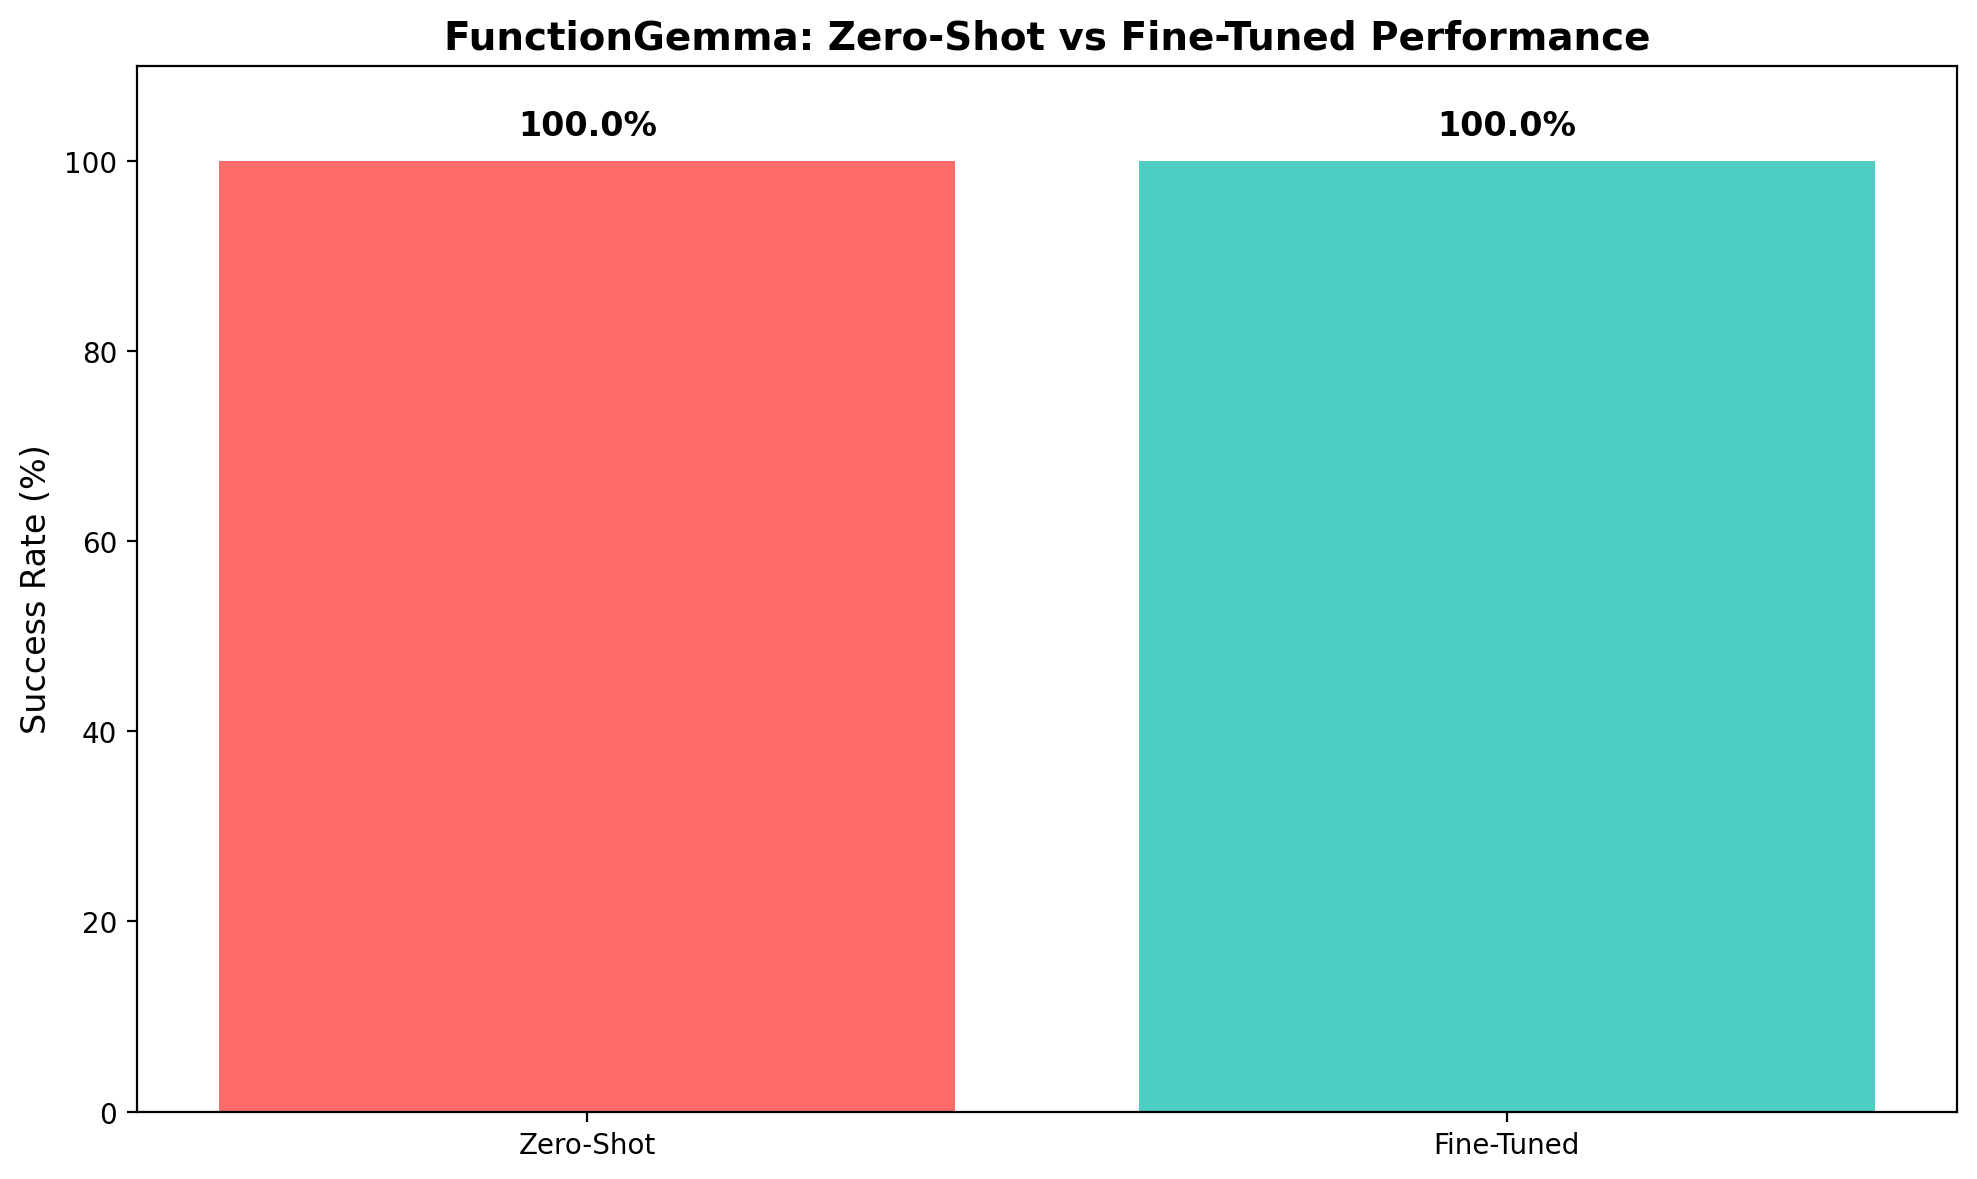

In [36]:
# Calculate success rates
df_comparison = pd.DataFrame(comparison)

zero_shot_success = df_comparison['zero_shot_success'].mean() * 100
fine_tuned_success = df_comparison['fine_tuned_success'].mean() * 100

print("\n" + "="*80)
print("PERFORMANCE COMPARISON")
print("="*80)
print(f"\nZero-Shot Success Rate: {zero_shot_success:.1f}%")
print(f"Fine-Tuned Success Rate: {fine_tuned_success:.1f}%")
print(f"\nImprovement: {fine_tuned_success - zero_shot_success:+.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
models = ['Zero-Shot', 'Fine-Tuned']
success_rates = [zero_shot_success, fine_tuned_success]

bars = ax.bar(models, success_rates, color=['#FF6B6B', '#4ECDC4'])
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('FunctionGemma: Zero-Shot vs Fine-Tuned Performance', fontsize=14, fontweight='bold')
ax.set_ylim(0, 110)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [37]:
# Detailed comparison table
print("\nDetailed Results:")
print(df_comparison[['question', 'zero_shot_success', 'fine_tuned_success']].to_string(index=False))


Detailed Results:
                                                      question  zero_shot_success  fine_tuned_success
    What is the total revenue for Laptops in the North region?               True                True
What's the average salary for Senior employees in Engineering?               True                True
                     Show me temperature statistics for London               True                True
                        What are the CO2 levels in Building_A?               True                True
